# EMA Support/Resistance Scanner

## Tool for Ranking Moving Averages by Market Interaction

## Table of contents

- [Core pipeline: Fetch → Analyze → Run functions](#Core-pipeline:-Fetch-→-Analyze-→-Run-functions)
- [Analysis](#Analysis)
  - [EMA as Support](#EMA-as-Support)
  - [EMA as Resistance](#EMA-as-Resistance)
  - [Universal EMA](#Universal-EMA)
- [Visual analysis](#Visual-analysis)
- [Backtesting](#Backtesting)
- [Data export](#Data-export)
- [Conclusion](#Conclusion)

__Goals:__
1. Build a ByBit Perpetual Futures EMA Touch / Cross Analyzer.
2. Quantify and compare EMA behavior to understand which periods price actually respects.

__Data:__ \
ByBit Perpetual Futures.

__Workflow:__ \
For each EMA period in a user-supplied range, every evaluated candle is placed in exactly one of five mutually-exclusive buckets, so the buckets always sum to evaluated_candles.

__Inputs:__
- symbol
- interval (ByBit codes: 1/3/5/15/30/60/120/240/360/720/D/W/M)
- start/end dates (YYYY-MM-DD)
- ema_range (any iterable of integers, e.g. range(1, 101) or [9, 21, 50, 200])
- delta
- delta_mode

__Delta modes:__
- "percent" — delta is a % of the EMA value at each candle (recommended, scales across price regimes) \
The allowed distance changes with price.
- "absolute" — delta is a fixed price distance in quote currency (e.g. USDT). Distance in price units. \
The allowed distance is always exactly the chosen 'number' regardless of price.

__Metric definitions__ (mutually exclusive partition; every candle lands in one bucket):
- cross      → Low ≤ EMA ≤ High. The candle's range straddles the EMA — the level was *broken*, not held.
- low_touch  → Low > EMA AND Low − EMA ≤ delta. Entire candle above EMA; low approached EMA from above without crossing — a *test of support*.
- high_touch → High < EMA AND EMA − High ≤ delta. Entire candle below EMA; high approached EMA from below without crossing — a *test of resistance*.
- above      → Low > EMA AND Low − EMA > delta. Entire candle above EMA, low far away — clean uptrend, no test.
- below      → High < EMA AND EMA − High > delta. Entire candle below EMA, high far away — clean downtrend, no test.

__Invariants:__
- cross + low_touch + high_touch + above + below = evaluated_candles
- any_touch = low_touch + high_touch (the two are mutually exclusive — a candle either tests support OR resistance, never both)

__Notes:__
- The first period candles are skipped per EMA (warm-up); toggle with skip_warmup=False if you don't want that.
- Pagination handles arbitrarily long date ranges (1000-candle chunks).
- Uses ewm(span=period, adjust=False) — standard Wilder/TradingView-style EMA.


## Core pipeline: Fetch → Analyze → Run functions

In [1]:
import time
import requests
import pandas as pd
import numpy as np
from typing import Iterable
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
BYBIT_API = "https://api.bybit.com/v5/market/kline"

__1. Data fetch__

In [3]:
def fetch_bybit_klines(
    symbol: str,
    interval: str,
    start: str,
    end: str,
    category: str = "linear",       # perpetual futures (USDT-margined)
) -> pd.DataFrame:
    """
    Pull kline data from ByBit v5 with automatic pagination.

    symbol   : e.g. "BTCUSDT"
    interval : "1","3","5","15","30","60","120","240","360","720","D","W","M"
    start/end: ISO date strings, e.g. "2024-01-01"
    category : "linear"  -> USDT perps (default)
               "inverse" -> coin-margined perps
    """
    # Convert dates to milliseconds
    # end date is exclusive
    # to extend to end-of-day (so include the end date): end_ts = int(pd.Timestamp(end, tz="UTC").timestamp() * 1000) + 86_400_000 - 1
    start_ts = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    end_ts   = int(pd.Timestamp(end,   tz="UTC").timestamp() * 1000)

    rows, cursor_end = [], end_ts

    while True:
        params = {
            "category": category,
            "symbol":   symbol.upper(),
            "interval": interval,
            "start":    start_ts,
            "end":      cursor_end,
            "limit":    1000,                 # ByBit max per request
        }
        r = requests.get(BYBIT_API, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()

        if data.get("retCode") != 0:
            raise RuntimeError(f"ByBit API error: {data}")

        batch = data["result"]["list"]        # newest first
        if not batch:
            break

        rows.extend(batch)

        # Result_list is sorted DESCENDING (newest candle first)
        oldest_ts = int(batch[-1][0])
        if oldest_ts <= start_ts or len(batch) < 1000:
            break
        # Move backward to fetch older candles
        cursor_end = oldest_ts - 1
        time.sleep(0.1)                       # polite rate-limiting

    if not rows:
        raise ValueError(
            f"No candles returned for {symbol} {interval} between {start} and {end}"
        )

    # Create DataFrame
    cols = ["timestamp", "open", "high", "low", "close", "volume", "turnover"]
    df = pd.DataFrame(rows, columns=cols)

    # Convert types
    df = df.astype({c: float for c in cols[1:]})
    df["timestamp"] = pd.to_datetime(df["timestamp"].astype(np.int64), unit="ms", utc=True)
    
    # Remove any duplicates and sort ascending by time
    df = (df.drop_duplicates("timestamp")
            .sort_values("timestamp")
            .reset_index(drop=True))
    
    # Filter exact date range (inclusive)
    df = df[(df["timestamp"] >= pd.Timestamp(start, tz="UTC")) &
            (df["timestamp"] <= pd.Timestamp(end,   tz="UTC"))].reset_index(drop=True)
    
    return df


__2. Touch / cross analysis__

Main algorithm:
1. Fetches ByBit perpetual futures data.
2. For every EMA period in ema_range:
   - Computes the EMA on close prices.
   - Assigns every evaluated candle to a category.
   - Categories are mutually exclusive.
3. Returns a clean DataFrame with one row per EMA period.


Partition table: every evaluated candle is placed in exactly one category.

| category     | condition                                                            | behavior | meaning |
|--------------|----------------------------------------------------------------------|---------|----------|
| cross      | Low ≤ EMA ≤ High | candle crosses EMA | level broken             |
| low_touch  | Low > EMA AND Low − EMA ≤ delta | entire candle above EMA, Low within delta of EMA, Low approached EMA from above | support held, no break |
| high_touch | High < EMA AND EMA − High ≤ delta | entire candle below EMA, High within delta of EMA, High approached EMA from below | resistance held, no break |
| above      | Low > EMA AND Low − EMA > delta | entire candle above EMA, Low further than delta | clean uptrend, no test of EMA |
| below      | High < EMA AND EMA − High > delta | entire candle below EMA, High further than delta | clean downtrend, no test of EMA |

Invariants:
- cross + low_touch + high_touch + above + below = evaluated_candles
- any_touch = low_touch + high_touch (mutually exclusive — a candle either tests support OR resistance, never both)


In [4]:
# skip_warmup=True: ignore the first N candles (where N = the EMA period)
# Example: For EMA 50, it throws away the first 50 candles and only counts touches/cross starting from candle 51.
# Set it to False if you want to include every candle regardless.

# delta %: the allowed distance changes with price
# delta absolute: the allowed distance is always exactly the chosen 'number' regardless of price

def analyze_ema_touches(
    df: pd.DataFrame,
    ema_range: Iterable[int],
    delta: float,
    delta_mode: str = "percent",   # "percent" (of EMA) or "absolute"
    skip_warmup: bool = True,
) -> pd.DataFrame:
    """
    Per EMA period, every evaluated candle is placed in exactly ONE of these
    mutually exclusive buckets:

        cross      : Low <= EMA <= High           (range straddles the EMA)
        low_touch  : Low > EMA  AND  Low - EMA  <= delta
                     (entire candle above EMA, low close enough to register a touch)
        high_touch : High < EMA  AND  EMA - High <= delta
                     (entire candle below EMA, high close enough to register a touch)
        above      : Low > EMA  AND  Low - EMA  > delta
                     (entire candle above EMA, low far from EMA = clean trend)
        below      : High < EMA  AND  EMA - High > delta
                     (entire candle below EMA, high far from EMA = clean trend)

    Invariants that always hold:
        cross + low_touch + high_touch + above + below = evaluated_candles
        any_touch = low_touch + high_touch  (no double counting)
    """
    close, high, low = df["close"], df["high"], df["low"]
    results = []

    for period in ema_range:
        # Compute EMA (pandas built-in, adjust=False = classic EMA)
        ema = close.ewm(span=period, adjust=False).mean()

        if delta_mode == "percent":
            tol = ema.abs() * (delta / 100.0)
        elif delta_mode == "absolute":
            tol = pd.Series(delta, index=ema.index)
        else:
            raise ValueError("delta_mode must be 'percent' or 'absolute'")

        # Optionally skip the first `period` candles while the EMA is warming up
        warmup = period if skip_warmup else 0
        mask = pd.Series(False, index=ema.index)
        mask.iloc[warmup:] = True

        # Top-level partition: cross / strictly-above / strictly-below
        crossed         = (low <= ema) & (ema <= high) & mask
        strictly_above  = (low > ema) & mask
        strictly_below  = (high < ema) & mask

        # Touches are *near approaches that did not cross* — split out from
        # strictly_above / strictly_below by the delta criterion.
        low_touch  = strictly_above & ((low  - ema) <= tol)
        high_touch = strictly_below & ((ema - high) <= tol)
        any_touch  = low_touch | high_touch

        # 'above' / 'below' = clean trending candles (strictly past EMA, NOT a touch)
        above = strictly_above & ~low_touch
        below = strictly_below & ~high_touch

        results.append({
            "ema":               period,
            "low_touch":         int(low_touch.sum()),
            "high_touch":        int(high_touch.sum()),
            "any_touch":         int(any_touch.sum()),
            "cross":             int(crossed.sum()),
            "above":             int(above.sum()),
            "below":             int(below.sum()),
            "evaluated_candles": int(mask.sum()),
        })

    return pd.DataFrame(results)


__3. Calling the fetch and analyze functions__

Configuration:
- interval = "60" for 1-hour candles
- ema_range  = range(5, 201, 5) calculates EMA 5, 10, 15, ..., 200
- delta_mode = "percent" or "absolute"
- delta %: the allowed distance between EMA and candle changes with price
- delta absolute: the allowed distance is always exactly the chosen 'number' regardless of price. Distance in price units.

*Examples:*
- delta=0.10 is 0.10 % of the EMA 
- a 5 USDT price difference in % is calculated as:  5 / price (e.g. 67,000) × 100 = 0.00746%
- a 0.0075% delta in USDT is calculated as: price (e.g. 67,000) × 0.0075 / 100 = 5.025 USDT

In [5]:
symbol     = "BTCUSDT"
interval   = "15"
start      = "2026-01-01"
end        = "2026-04-01"
ema_range  = range(1, 200, 1)
delta      = 20
delta_mode = "absolute"

Dataframe of raw OHLCV candles (klines) from ByBit:

In [6]:
df = fetch_bybit_klines(symbol, interval, start, end)

print(f"Fetching {symbol} interval={interval} from {start} to {end} ...")
print(f"  -> {len(df)} candles downloaded.")

Fetching BTCUSDT interval=15 from 2026-01-01 to 2026-04-01 ...
  -> 8641 candles downloaded.


Dataframe of candle categories per EMA period:

In [7]:
result = analyze_ema_touches(df, ema_range, delta, delta_mode)

result.head(10).style.hide(axis="index")

ema,low_touch,high_touch,any_touch,cross,above,below,evaluated_candles
1,0,0,0,8640,0,0,8640
2,30,33,63,8570,3,3,8639
3,159,130,289,8136,110,103,8638
4,289,239,528,7396,362,351,8637
5,369,346,715,6615,673,633,8636
6,375,405,780,5915,997,943,8635
7,433,426,859,5303,1231,1241,8634
8,415,399,814,4847,1470,1502,8633
9,399,393,792,4508,1648,1684,8632
10,411,383,794,4168,1811,1858,8631


__Alternative: convenience wrapper__

In [ ]:
# def run(
#     symbol: str,
#     interval: str,
#     start: str,
#     end: str,
#     ema_range: Iterable[int],
#     delta: float,
#     delta_mode: str = "percent",
# ) -> tuple[pd.DataFrame, pd.DataFrame]:
#     print(f"Fetching {symbol} interval={interval} from {start} to {end} ...")
    
#     df = fetch_bybit_klines(symbol, interval, start, end)
#     print(f"  -> {len(df)} candles downloaded")

#     result = analyze_ema_touches(df, ema_range, delta, delta_mode)
#     return df, result

In [ ]:
# symbol     = "BTCUSDT"
# interval   = "15"
# start      = "2026-01-01"
# end        = "2026-04-01"
# ema_range  = range(1, 200, 1)
# delta      = 40
# delta_mode = "absolute"

In [ ]:
# df, result = run(symbol, interval, start, end, ema_range, delta, delta_mode)

## Analysis

__Distributions of EMA periods across candle categories.__

EMA periods are grouped by their count for each candle category.

For each candle category, the histogram shows how the count is distributed across the EMA range — i.e. how many EMAs had ~100 touches, ~500, ~2000, etc.

Use it to see the bulk vs. the tails: where most EMAs cluster (typical behavior) and which ones sit far from the pack (outliers worth a closer look).

Chart explanation:
- each chart counts EMA periods, not candles
- the x-axis is "number of times this candle behavior happened"
- the y-axis is "how many EMAs had that number"
- a tall bar in the middle → most EMAs behave this way. That's the typical range.
- short bars far on the sides → a few EMAs whose counts are unusually high or low. Those are the outliers worth a closer look.


For example, the low_touch histogram:
- Answers "how many of the 199 EMAs had around 100 low_touches? around 300? around 400?"
- Each of the 199 EMAs has a low_touch count (e.g. EMA-1 → 0, EMA-50 → 289, EMA-200 → 18).
- The histogram bins those 199 numbers and shows how many EMAs fall into each bin.
- So if 12 EMAs had between 240 and 260 low_touches, the bar centered at 250 has height 12.

array([[<Axes: title={'center': 'low_touch'}>,
        <Axes: title={'center': 'high_touch'}>],
       [<Axes: title={'center': 'any_touch'}>,
        <Axes: title={'center': 'cross'}>],
       [<Axes: title={'center': 'above'}>,
        <Axes: title={'center': 'below'}>]], dtype=object)

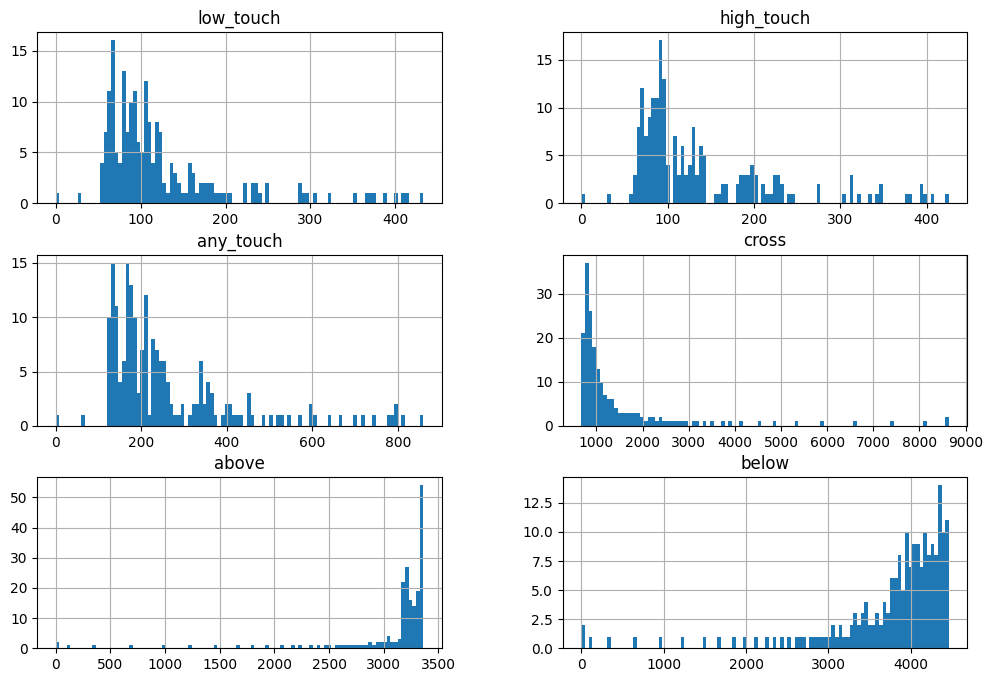

In [20]:
result[["low_touch", "high_touch", "any_touch", "cross", "above", "below"]].hist(bins=100, figsize=(12, 8)) 

__Which EMA values were touched most often by candle Lows?__

In [11]:
emas_sorted_by_lows = (result[["ema", "low_touch"]]
           .sort_values("low_touch", ascending=False)
           .set_index("ema"))

emas_sorted_by_lows

,low_touch
ema,
7,433
8,415
10,411
9,399
11,388
...,...
181,55
178,53
179,52


__Which EMA values were touched most often by candle Highs?__

In [12]:
emas_sorted_by_highs = (result[["ema", "high_touch"]]
           .sort_values("high_touch", ascending=False)
           .set_index("ema"))

emas_sorted_by_highs

,high_touch
ema,
7,426
6,405
8,399
11,396
9,393
...,...
170,63
195,60
196,58


__Which EMA values had the most candles floating entirely above them?__

Price spent most of the period trending above this EMA (EMA acted as a floor / bullish regime).

In [13]:
emas_sorted_by_above = (result[["ema", "above"]]
           .sort_values("above", ascending=False)
           .set_index("ema"))

emas_sorted_by_above

,above
ema,
106,3362
107,3358
90,3357
89,3357
104,3357
...,...
5,673
4,362
3,110


__Which EMA values had the most candles floating entirely below them?__

Price spent most of the period trending below this EMA (EMA acted as a ceiling / bearish regime).

In [14]:
emas_sorted_by_below = (result[["ema", "below"]]
           .sort_values("below", ascending=False)
           .set_index("ema"))

emas_sorted_by_below

,below
ema,
199,4463
197,4463
196,4461
198,4460
195,4455
...,...
5,633
4,351
3,103


### EMA as Support

Which formula to use?

| formula | meaning | what it measures | usage |
|---|---|---|---|
| low_touch / cross | support strength conditional on a test | Of the times price came down to the EMA, what fraction bounced vs. broke through? | support-quality metric |
| low_touch / evaluated_candles | frequency of clean support tests | How often does this EMA come into play at all? | activity gauge |
| (low_touch + above) / cross | bullishness of the period at this EMA | How dominant is the "above" side relative to break-throughs? | trend-bias ratio |
| (low_touch + above) / evaluated_candles | regime indicator | Fraction of time price was above the EMA. | trend filter |

__Is this EMA a good support level to trade?__

EMA as a support quality metric: is this EMA a reliable bounce level?

ratio_support shows % of tests that held:
- 0.0 → every approach broke through (no holds)
- 0.5 → bounces half the time when tested
- 1.0 → every approach held (perfect support)

High ratio = EMA acts as support: price dips down to it, touches it, bounces without getting sliced through.

In [21]:
# replace(0, np.nan) handles division by zero (if an EMA happens to have 0 cross)
# use copy() to avoid the pandas SettingWithCopyWarning and to make sure the next line doesn't mutate the original result DataFrame
# with .copy(): ratio_support is guaranteed to be a new DataFrame — modifications stay local, no warning, no risk of side effects on result
# Rule: any time you take a column subset and plan to write to it, append .copy(). This matters in a notebook with multiple analysis sections all reading from the same DataFrame.

ratio_support = result[["ema", "low_touch", "cross"]].copy()
ratio_support["ratio_support"] = ratio_support["low_touch"] / (ratio_support["low_touch"] + ratio_support["cross"]).replace(0, np.nan)
ratio_support = ratio_support.sort_values("ratio_support", ascending=False).set_index("ema")

ratio_support

,low_touch,cross,ratio_support
ema,,,
114,125,920,0.119617
115,119,913,0.115310
113,120,921,0.115274
116,114,908,0.111546
117,109,912,0.106758
...,...,...,...
5,369,6615,0.052835
4,289,7396,0.037606
3,159,8136,0.019168


*Result:*
- With delta 20: ratios around 0.12 for EMAs: 114, 115, 113, 116.
- With delta 40: ratio 0.425 for EMAs: 118, 115, and ratio 0.422 for EMAs: 114, 117, 116.
- With delta 50: ratio 0.517 for EMAs: 114, 118, and ratio 0.515 for EMAs: 113, 116, 117.

*Conclusion:*
- Slow EMAs (above 100) will naturally score highest on this metric because price rarely reaches them at all: so both touches and cross are low, but cross drop faster.
- Ratio ceiling around 0.42 means even the best support EMA only supported ~42% of the time price reached it. \
The other ~58% of cross, price cut through. In a trending market that's normal.

__How often does this EMA come into play at all?__

Evaluates how often the setup shows up, not how good it is when it does.

In [22]:
ratio_support_1 = result[["ema", "low_touch", "evaluated_candles"]].copy()
ratio_support_1["ratio_support_1"] = ratio_support_1["low_touch"] / ratio_support_1["evaluated_candles"].replace(0, np.nan)
ratio_support_1 = ratio_support_1.sort_values("ratio_support_1", ascending=False).set_index("ema")

ratio_support_1

,low_touch,evaluated_candles,ratio_support_1
ema,,,
7,433,8634,0.050151
8,415,8633,0.048071
10,411,8631,0.047619
9,399,8632,0.046223
11,388,8630,0.044959
...,...,...,...
181,55,8460,0.006501
178,53,8463,0.006263
179,52,8462,0.006145


__What's the trend bias around this EMA?__

A regime signal: high ratio means price spent the period mostly above the EMA.

Treats "price floated above the EMA" as a form of support, not just direct touches.

Captures EMAs acting as a floor during bullish/trending regimes, where price often respects the level without dipping into touch distance.

- Combines direct touches from above (low_touch) with candles that stayed entirely above the EMA (above).
- Unlike ratio_support, this rewards EMAs that acted as a floor during trending stretches where price never dipped close enough to register a touch.
- Useful in strong uptrends where pure touch-based ratios under-count respected levels.

In [23]:
ratio_support_2 = result[["ema", "low_touch", "above", "cross"]].copy()
ratio_support_2["ratio_support_2"] = (ratio_support_2["low_touch"] + ratio_support_2["above"]) / ratio_support_2["cross"].replace(0, np.nan)
ratio_support_2 = ratio_support_2.sort_values("ratio_support_2", ascending=False).set_index("ema")

ratio_support_2

,low_touch,above,cross,ratio_support_2
ema,,,,
199,69,3163,674,4.795252
198,70,3163,679,4.761414
197,60,3169,688,4.693314
196,64,3170,692,4.673410
195,61,3173,697,4.639885
...,...,...,...,...
5,369,673,6615,0.157521
4,289,362,7396,0.088021
3,159,110,8136,0.033063


__Filtering out tiny sample sizes.__

An EMA with 3 touches and 1 cross has a ratio of 3.0, but it's based on only 3 touches over the whole period — statistically meaningless. \
Other EMAs might have a lower ratio but a lot of touches, which provides a much more reliable signal.

Rule of thumb for a threshold: \
Require at least ~1 touch per week of data, or whatever feels statistically reasonable for your timeframe. \
E.g. 8640 candles of 15-min data = 90 days. MIN_TOUCHES = 30 means roughly one touch every 3 days — a reasonable floor.

In [24]:
# pick a threshold for the minimum sample size that feels right for your dataset

MIN_TOUCHES_SUP = 30

ratio_support_filtered = ratio_support[ratio_support["low_touch"] >= MIN_TOUCHES_SUP]
ratio_support_filtered

,low_touch,cross,ratio_support
ema,,,
114,125,920,0.119617
115,119,913,0.115310
113,120,921,0.115274
116,114,908,0.111546
117,109,912,0.106758
...,...,...,...
6,375,5915,0.059618
5,369,6615,0.052835
4,289,7396,0.037606


__Low touch vs cross by EMA period.__

Visualization of how often each EMA was touched vs crossed by candle Lows, plus their ratio.

Plots low_touch and cross as overlapping bars across all EMA periods, \
with the touch/cross ratio drawn as a red line on a secondary axis. \
Allows to see raw activity and the resistance ratio on one chart.

Result: a dual-axis chart
- bars for the raw counts
- a red line for the ratio

In [35]:
ratio = result["low_touch"] / (result["low_touch"] + result["cross"]).replace(0, np.nan)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=result["ema"], y=result["cross"], name="cross",
           marker_color="steelblue", opacity=0.4),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=result["ema"], y=result["low_touch"], name="low_touch",
           marker_color="orange", opacity=0.7),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=result["ema"], y=ratio, name="support probability",
               mode="lines", line=dict(color="red", width=2),
               hovertemplate="%{y:.1%}"),
    secondary_y=True,
)

fig.update_layout(
    title="Low touches vs cross by EMA period — with support probability",
    barmode="overlay",
    template="plotly_white",
    height=500,
    hovermode="x unified",
    hoverlabel=dict(namelength=-1),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.update_xaxes(title_text="EMA period", tickprefix="EMA ")
fig.update_yaxes(title_text="Count", secondary_y=False)
fig.update_yaxes(title_text="Support probability", secondary_y=True, color="red", tickformat=".0%")

fig.show()

Use it for:
- Where the ratio peaks (the red line reaches its highest points on the chart) across the EMA spectrum —> EMAs periods that acted as the best support.
- Are they isolated spikes or broad hills (a whole zone respects support)?
- Whether high-ratio EMAs are backed by real volume of touches, or just low cross (thin bars under a high red line = suspicious).
- Trend in the counts — do touches/cross fall off smoothly as EMA period grows, or are there anomalies?

### EMA as Resistance

High ratio = EMA acts as resistance: price rallies up into it, the candle's High kisses it (within delta), and then price rejects back down without the candle slicing through.

Common expectations:

__On a 15-min chart__: \
Slow EMAs like 99, 144 and 200 often score high on ratio because price rarely reaches them, and when it does it often rejects cleanly.

__In a downtrending or ranging market:__ \
The classic "respected resistance" EMAs tend to rise to the top:
- EMA 20 — short-term resistance, widely watched by intraday traders
- EMA 50 — medium-term, very popular on daily charts, often respected on lower timeframes too
- EMA 200 — long-term, the "institutional" line, strong resistance in downtrends

__In a strong uptrend:__ \
Resistance EMAs barely exist — price stays above most EMAs, so high_touch will be low across the board and the ratio becomes noisy. \
The top of ranked might be dominated by random slow EMAs with tiny sample sizes.

__Adjacent EMAs clustering with nearly identical ratios:__ \
It is the signature of a real resistance zone. Example:
- EMA 47–50 zone — 694–729 touches (huge sample), ratio ~0.46
- EMA 85–87 zone — 487–492 touches, ratio ~0.46 \
-> Price on the chart was genuinely respecting levels near the 50-EMA and near the 86-EMA.

In [28]:
ratio_resistance = result[["ema", "high_touch", "cross"]].copy()
ratio_resistance["ratio_resistance"] = ratio_resistance["high_touch"] / (ratio_resistance["high_touch"] + ratio_resistance["cross"]).replace(0, np.nan)
ratio_resistance = ratio_resistance.sort_values("ratio_resistance", ascending=False).set_index("ema")

ratio_resistance

,high_touch,cross,ratio_resistance
ema,,,
85,142,1064,0.117745
46,216,1620,0.117647
53,190,1430,0.117284
47,210,1594,0.116408
82,143,1095,0.115509
...,...,...,...
5,346,6615,0.049706
4,239,7396,0.031303
3,130,8136,0.015727


*Result:*
- With delta 20: ratios around 0.12 for EMAs: 85, 46, 53, 47, 82.
- With delta 30: ratio 0.348 for EMAs: 47, 85, 84, 87.
- With delta 40: ratio 0.462 for EMAs: 86, 87, and ratio 0.459 for EMAs: 50, 85, 47.
- With delta 50: ratio 0.565 for EMAs: 77, 76, and ratio 0.562 for EMAs: 47, 50, 49.

*Conclusion:*
- Two distinct resistance clusters emerged: EMA 47–50 zone and EMA 85–87 zone.
- Sample sizes are strong. Even the 85–87 cluster has ~490 touches.
- The 50 EMA showing up is classic. It's the most-watched medium-term EMA on any timeframe. \
The data shows it worked as resistance during the selected time window and the price showed genuine mean-reversion behavior.
- Fast EMAs (1–5) at the bottom are expected. \
They hug price too tightly, so cross dominate (8640 cross for EMA 1 = every single candle). \
Low ratio = they don't act as resistance, they are price.
- Ratio ceiling around 0.46 means even the best resistance EMA only rejected ~46% of the time price reached it. \
The other ~54% of cross, price cut through. In a trending market that's normal.

__Broader resistance ratio variant.__

Treats "price floated below the EMA" as a form of resistance, not just direct touches.

Captures EMAs acting as a ceiling during bearish/trending regimes, where price often respects the level without rallying into touch distance.

- Combines direct touches from below (high_touch) with candles that stayed entirely below the EMA (below).
- Unlike ratio_resistance, this rewards EMAs that acted as a ceiling during trending stretches where price never rallied close enough to register a touch.
- Useful in strong downtrends where pure touch-based ratios under-count respected levels.

In [29]:
ratio_resistance_2 = result[["ema", "high_touch", "below", "cross"]].copy()
ratio_resistance_2["ratio_resistance_2"] = (ratio_resistance_2["high_touch"] + ratio_resistance_2["below"]) / ratio_resistance_2["cross"].replace(0, np.nan)
ratio_resistance_2 = ratio_resistance_2.sort_values("ratio_resistance_2", ascending=False).set_index("ema")

ratio_resistance_2

,high_touch,below,cross,ratio_resistance_2
ema,,,,
199,73,4463,674,6.729970
198,71,4460,679,6.673049
197,64,4463,688,6.579942
196,58,4461,692,6.530347
195,60,4455,697,6.477762
...,...,...,...,...
5,346,633,6615,0.147997
4,239,351,7396,0.079773
3,130,103,8136,0.028638


__Filtering out tiny sample sizes.__

In [30]:
# pick a threshold for the minimum sample size that feels right for your dataset

MIN_TOUCHES_RES = 30

ratio_resistance_filtered = ratio_resistance[ratio_resistance["high_touch"] >= MIN_TOUCHES_RES]
ratio_resistance_filtered

,high_touch,cross,ratio_resistance
ema,,,
85,142,1064,0.117745
46,216,1620,0.117647
53,190,1430,0.117284
47,210,1594,0.116408
82,143,1095,0.115509
...,...,...,...
6,405,5915,0.064082
5,346,6615,0.049706
4,239,7396,0.031303


__High touch vs cross by EMA period.__

Visualization of how often each EMA was touched vs crossed by candle Highs, plus their ratio.

Plots high_touch and cross as overlapping bars across all EMA periods, \
with the touch/cross ratio drawn as a red line on a secondary axis. \
Allows to see raw activity and the resistance ratio on one chart.

Result: a dual-axis chart
- bars for the raw counts
- a red line for the ratio

In [36]:
ratio = result["high_touch"] / (result["high_touch"] + result["cross"]).replace(0, np.nan)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=result["ema"], y=result["cross"], name="cross",
           marker_color="steelblue", opacity=0.4),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=result["ema"], y=result["high_touch"], name="high_touch",
           marker_color="orange", opacity=0.7),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=result["ema"], y=ratio, name="support probability",
               mode="lines", line=dict(color="red", width=2),
               hovertemplate="%{y:.1%}"),
    secondary_y=True,
)

fig.update_layout(
    title="High touches vs cross by EMA period — with support probability",
    barmode="overlay",
    template="plotly_white",
    height=500,
    hovermode="x unified",
    hoverlabel=dict(namelength=-1),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.update_xaxes(title_text="EMA period", tickprefix="EMA ")
fig.update_yaxes(title_text="Count", secondary_y=False)
fig.update_yaxes(title_text="support probability", secondary_y=True, color="red", tickformat=".0%")

fig.show()

Use it for:
- Where the ratio peaks (the red line reaches its highest points on the chart) across the EMA spectrum —> EMAs periods that acted as the best resistance.
- Are they isolated spikes or broad hills (a whole zone respects resistance)?
- Whether high ratios are backed by real volume of touches, or just low cross (thin bars under a high red line = suspicious).
- Trend in the counts — do touches/cross fall off smoothly as EMA period grows, or are there anomalies?

### Universal EMA

EMA as any kind of S/R.

In [32]:
# Combining both touches to analyze EMA as any kind of S/R
ratio_universal = result[["ema", "any_touch", "cross"]].copy()
ratio_universal["ratio_universal"] = ratio_universal["any_touch"] / (ratio_universal["any_touch"] + ratio_universal["cross"]).replace(0, np.nan)
ratio_universal = ratio_universal.sort_values("ratio_universal", ascending=False).set_index("ema")

ratio_universal.head(10)

,any_touch,cross,ratio_universal
ema,,,
53,349,1430,0.196178
100,236,977,0.194559
55,336,1392,0.194444
52,343,1462,0.190028
85,249,1064,0.189642
101,227,971,0.189482
115,212,913,0.188444
98,230,991,0.188370
143,192,828,0.188235


*Result:*
- With delta 20: ratios around 0.20 for EMAs: 53, 100, 55, 52.
- With delta 30: ratio 0.63 for EMAs: 53, 116, 87, 18.
- With delta 40: ratio 0.83 for EMAs: 18, 50, and ratio 0.82 for EMAs: 19, 20.
- With delta 50: ratio 1 for EMAs: 50, 53, 55, 49, 52, 56.

__Filtering out tiny sample sizes.__

In [33]:
# pick a threshold for the minimum sample size that feels right for your dataset

MIN_TOUCHES_UNI = 60

ratio_universal_filtered = ratio_universal[ratio_universal["any_touch"] >= MIN_TOUCHES_UNI]
ratio_universal_filtered

,any_touch,cross,ratio_universal
ema,,,
53,349,1430,0.196178
100,236,977,0.194559
55,336,1392,0.194444
52,343,1462,0.190028
85,249,1064,0.189642
...,...,...,...
6,780,5915,0.116505
5,715,6615,0.097544
4,528,7396,0.066633


__Any touch vs cross by EMA period.__

In [37]:
ratio = result["any_touch"] / (result["any_touch"] + result["cross"]).replace(0, np.nan)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=result["ema"], y=result["cross"], name="cross",
           marker_color="steelblue", opacity=0.4),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=result["ema"], y=result["any_touch"], name="any_touch",
           marker_color="orange", opacity=0.7),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=result["ema"], y=ratio, name="support probability",
               mode="lines", line=dict(color="red", width=2),
               hovertemplate="%{y:.1%}"),
    secondary_y=True,
)

fig.update_layout(
    title="Any touch vs cross by EMA period — with support probability",
    barmode="overlay",
    template="plotly_white",
    height=500,
    hovermode="x unified",
    hoverlabel=dict(namelength=-1),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.update_xaxes(title_text="EMA period", tickprefix="EMA ")
fig.update_yaxes(title_text="Count", secondary_y=False)
fig.update_yaxes(title_text="Support probability", secondary_y=True, color="red", tickformat=".0%")

fig.show()


What you see on the chart:
- Fast EMAs (left side) \
Huge blue bars (crosses), smaller orange bars (touches), low red line (ratio). \
EMA hugs price, gets sliced constantly.
- Medium EMAs (middle) \
Blue and orange come closer together, red line rises. This is the sweet spot.
- Slow EMAs (right side) \
Both bars shrink (price rarely reaches them), red line may spike due to low denominators. Watch for noise here.

The red line's peak is where the best S/R candidates are.

## Visual analysis

An interactive financial chart in Plotly:
- Overlays EMAs on a candlestick chart to see if they line up with swing highs and lows.
- Chart opens showing the last 3 days.
- Drag the range slider or click 1d/1w/1m/3m buttons to jump to different windows.
- After jumping, click the "Autoscale" button in the top-right toolbar to rescale y-axis. Double-clicking the y-axis also works.

Change pd.Timedelta(days=3) if you want a different default window:
- days=1 for tighter zoom
- days=7 for a weekly view

__Configurable parameters:__

In [39]:
symbol                                           # label for the candlestick trace and title, configured at data loading
ema_periods     = [53, 85, 114]                  # a list with any number of EMA periods
ema_colors      = ["orange", "blue", "purple"]   # one color per period
initial_window  = pd.Timedelta(days=30)          # default zoom: how much history to show on load
chart_height    = 900

In [40]:
# Compute EMAs dynamically
for period in ema_periods:
    df[f"ema_{period}"] = df["close"].ewm(span=period, adjust=False).mean()

fig = go.Figure()

# Price candles
fig.add_trace(go.Candlestick(
    x=df["timestamp"],
    open=df["open"], high=df["high"], low=df["low"], close=df["close"],
    name=symbol,
))

# EMA lines
for period, color in zip(ema_periods, ema_colors):
    fig.add_trace(go.Scatter(
        x=df["timestamp"],
        y=df[f"ema_{period}"],
        line=dict(color=color, width=1.5),
        name=f"EMA {period}",
    ))

# Default view: last N days
initial_start = df["timestamp"].iloc[-1] - initial_window
initial_end   = df["timestamp"].iloc[-1]

# Title built from config
ema_label = " & ".join(f"EMA {p}" for p in ema_periods)
chart_title = f"{symbol} — {ema_label}"

fig.update_layout(
    title=chart_title,
    height=chart_height,
    template="plotly_white",
    xaxis=dict(
        range=[initial_start, initial_end],
        rangeslider=dict(visible=True, thickness=0.04),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1d", step="day",   stepmode="backward"),
                dict(count=7, label="1w", step="day",   stepmode="backward"),
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(step="all", label="All"),
            ]
        ),
    ),
    yaxis=dict(autorange=True, fixedrange=False),
)

fig.show()

## Backtesting

Translates the EMA touch analysis into a fully simulated trading strategy with realistic execution (fees + slippage), configurable stop loss / take profit / position sizing, and per-trade metrics including expectancy, profit factor, max drawdown, and exit-reason breakdown.

__Strategy logic:__
- Entry timing: at the close of the touch candle, with slippage applied.
- Long Entry: a candle's Low touches a chosen support EMA (within delta) and the candle closes back at/above the EMA (rejection). \
  Optionally gated by close > EMA(regime_filter).
- Short entry: a candle's High touches a chosen resistance EMA (within delta) and the candle closes back at/below the EMA (rejection). \
  Optionally gated by close < EMA(regime_filter).
- One position at a time.
- Exit: stop loss, take profit, or end-of-data — whichever fires first. \
  If both SL and TP are reachable in the same candle, SL is assumed to fire first (conservative).

__Optional regime_filter:__
- adds a broader trend check
- it is a second, optional entry condition that has to also be true for an entry to fire

The default entry signal is local: it tells you about the immediate behavior around the entry EMA, but says nothing about the broader trend. \
If you set regime_filter=200, the engine computes a second, slower EMA (e.g. EMA-200) and only allows a long entry when the touch candle's close is above it. \
What it means: "I'm only willing to buy a pullback if the bigger picture is also bullish (price above EMA-200)." \
Mirror logic for shorts: close < EMA(regime_filter) — you only short rallies when the broader trend is also down.

*Example:* \
BTC is in a long downtrend on the daily but pulled back UP to a fast 20-EMA on the 15-min and bounced. \
Without a regime filter, the strategy buys that bounce — and gets crushed when the daily downtrend resumes. \
With regime_filter=200, the engine refuses to buy because close < EMA-200 (the macro trend is down), and you avoid the trap.

__Configurable knobs:__
- direction: long / short / both
- stop_loss.mode: fixed_value | fixed_pct | beyond_ema | trailing | chandelier
- take_profit.mode: fixed_value | fixed_pct | r_multiple | trailing
- position_sizing.mode: fixed_value (notional in quote ccy) | fixed_pct (% of equity)
- fee_pct: per-fill, in % (e.g. 0.055 for ByBit taker)
- slippage_pct: per-fill, in % of price
- regime_filter: none, longs only when close > EMA(N), shorts only when close < EMA(N)

### 1. Setup

Single import + autoreload so edits to backtest.py hot-reload without restarting the kernel.

In [41]:
# Engine + visualisation lives in backtest.py — import once and call from the cells below.
# %autoreload picks up edits to backtest.py without restarting the kernel.
# You only need to run them once per kernel session. Subsequent edits to backtest.py will pick up automatically without re-importing or restarting.

%load_ext autoreload
%autoreload 2

from dataclasses import replace
from backtest import (
    StopLossConfig, TakeProfitConfig, PositionSizingConfig, StrategyConfig,
    backtest, compute_metrics, print_metrics,
    plot_equity_curve, plot_trades_on_chart,
    walk_forward_split,
    sweep_configs, sweep_grid,
)

### 2. Helpers used here

These two pickers stay in the notebook (rather than backtest.py) because they consume the analyze_ema_touches output defined earlier.

In [ ]:
def pick_best_ema_support(train_df: pd.DataFrame, ema_range: Iterable[int],
                          delta: float, delta_mode: str,
                          min_touches: int = 30) -> int:
    """Return the EMA period with the highest support ratio on the train slice."""
    res = analyze_ema_touches(train_df, ema_range, delta, delta_mode)
    res = res[res["low_touch"] >= min_touches].copy()
    if len(res) == 0:
        raise ValueError(f"No EMA met min_touches={min_touches} on train slice")
    res["ratio_support"] = res["low_touch"] / (res["low_touch"] + res["cross"]).replace(0, np.nan)
    best = res.sort_values("ratio_support", ascending=False).iloc[0]
    return int(best["ema"])


def pick_best_ema_resistance(train_df: pd.DataFrame, ema_range: Iterable[int],
                             delta: float, delta_mode: str,
                             min_touches: int = 30) -> int:
    """Return the EMA period with the highest resistance ratio on the train slice."""
    res = analyze_ema_touches(train_df, ema_range, delta, delta_mode)
    res = res[res["high_touch"] >= min_touches].copy()
    if len(res) == 0:
        raise ValueError(f"No EMA met min_touches={min_touches} on train slice")
    res["ratio_resistance"] = res["high_touch"] / (res["high_touch"] + res["cross"]).replace(0, np.nan)
    best = res.sort_values("ratio_resistance", ascending=False).iloc[0]
    return int(best["ema"])


### 3. Capital, sizing, fees, slippage

__Sizing & capital — what to set, and why it matters__

The position sizer turns a notional dollar amount into a coin quantity. ByBit's BTCUSDT minimum is __0.001 BTC__, so any trade whose computed size falls below that gets skipped (the engine prints a warning the first time and a count at the end of the run).

To clear the floor, your per-trade notional must be ≥ min_size × price. At BTC ≈ $70k that's ~__$70 per trade__; at $100k it's ~$100. So:

- position_sizing=fixed_pct(10) on initial_capital=10_000 → $1000/trade. Comfortable across all BTC price levels and through deep drawdowns.
- position_sizing=fixed_pct(10) on initial_capital=1_000 → $100/trade. Works at BTC ≤ ~$100k, but a >30% drawdown shrinks notional below the floor and trades start getting silently skipped.
- position_sizing=fixed_pct(10) on initial_capital=100 → $10/trade. Always below the floor at any plausible BTC price → __zero trades__.
- position_sizing=fixed_value(100) → flat $100/trade regardless of equity. Cleanest way to test on small capital; tradeoff is no compounding on the upside and no automatic de-risking on the downside.

Friction matters more on small capital. ByBit taker fee 0.055% × 2 fills + slippage = ~0.13% per round-trip. On a $100 notional that's ~$0.13/trade — same in absolute terms regardless of equity, but a larger fraction of a smaller account.

__Rule of thumb:__ pick capital and sizing such that even a 30–50% drawdown still produces notional ≥ min_size × max_expected_price. If you want to backtest realistically on a small account, use fixed_value sizing.


### 4. Walk-forward split + EMA selection

70/30 split — fit on the first 70% (train), evaluate on the held-out 30% (test). Pick the best EMA on train only via ratio_support (longs) or ratio_resistance (shorts). Anything refitted on test is overfit by definition.

In [ ]:
# Reuse `df` already fetched above.
# Default config: longs only, 1% fixed stop loss, 3R take-profit, 10% of equity per trade, 0.055% ByBit taker fee , 0.01% slippage. 
# EMA chosen via support ratio on a train slice.

train_df, test_df = walk_forward_split(df, train_pct=0.7)
print(f"Train: {train_df['timestamp'].iloc[0]} → {train_df['timestamp'].iloc[-1]}  ({len(train_df)} candles)")
print(f"Test:  {test_df['timestamp'].iloc[0]} → {test_df['timestamp'].iloc[-1]}  ({len(test_df)} candles)")

best_ema = pick_best_ema_support(train_df, ema_range=range(15, 200), delta=delta, delta_mode=delta_mode, min_touches=20)
print(f"Best support EMA on train: {best_ema}")


### 5. Strategy configuration

Assemble the StrategyConfig from the sizing / fee choices above and the EMA picked on train.

In [ ]:
cfg = StrategyConfig(
    direction="long",
    ema_period=best_ema,
    delta=delta,
    delta_mode=delta_mode,
    stop_loss=StopLossConfig(mode="fixed_pct", value=1.0),       # 1% stop
    take_profit=TakeProfitConfig(mode="r_multiple", value=3.0),  # 3R target
    position_sizing=PositionSizingConfig(mode="fixed_value", value=100.0),  # fixed_pct is % of equity per trade
    fee_pct=0.055,        # ByBit taker
    slippage_pct=0.01,    # 0.01% of price
    initial_capital=100.0,
)
cfg


### 6. Run on train (in-sample)

Fit the strategy to the training slice. The numbers below will look optimistic — that's expected; the test slice (next section) is the honest read.

In [ ]:
trades_train, equity_train = backtest(train_df, cfg)
metrics_train = compute_metrics(trades_train, equity_train, cfg.initial_capital)
print_metrics(metrics_train)

Equity curve and drawdown over time.

In [ ]:
plot_equity_curve(equity_train, cfg.initial_capital, title=f"Equity curve — train (EMA {cfg.ema_period})")

Trades on the price chart — blue ▲ longs, red ▼ shorts, ✕ exits color-coded by reason.

In [ ]:
plot_trades_on_chart(train_df, trades_train, cfg, initial_window_days=30)

### 7. Run on test (out-of-sample) — the honest number

Same config on data the EMA picker never saw. If train and test agree (both positive after fees), there's a candidate edge. If test collapses while train looked great, the EMA selection over-fit.

In [ ]:
trades_test, equity_test = backtest(test_df, cfg)
metrics_test = compute_metrics(trades_test, equity_test, cfg.initial_capital)
print_metrics(metrics_test)

Equity curve and drawdown over time.

In [ ]:
plot_equity_curve(equity_test, cfg.initial_capital, title=f"Equity curve — test (EMA {cfg.ema_period})")

Trades on the price chart — blue ▲ longs, red ▼ shorts, ✕ exits color-coded by reason.

In [ ]:
plot_trades_on_chart(test_df, trades_test, cfg, initial_window_days=30)

### 8. Reading the result

- If __test expectancy > 0 after fees__ and is in the same ballpark as train → there's a real edge worth paper-trading next.
- If __test expectancy < 0__ while train was positive → the EMA selection over-fit the train slice. Try a coarser ema_range, a longer history, or different delta.
- If __profit factor < 1.2__ on test → edge is too thin to survive real-world frictions you didn't model (funding, partial fills, exchange downtime).
- __Exit reason mix__ tells you whether the 3R target is realistic. If stop_loss >> take_profit, you're getting stopped out before the move develops — try wider stops, lower R-targets, or a slower EMA.

__Next iterations__ (separate experiments, not this run):
1. Sweep EMA period × stop% × R-target on train, pick top 3 by Sortino, validate each on test.
2. Sweep direction (long / short / both). In a chop-heavy regime both typically beats either side alone because mean-reversion fires on both swings; in strong trends, the trending direction wins.
3. Add a regime filter (e.g. only trade longs when price is above a slow EMA like 200) to skip counter-trend stretches.
4. Replace single-asset with a basket (BTC + ETH + a couple of liquid alts) — diversifies the edge.

Train and test agree → not curve-fit, just a non-edge as configured. \
The 3R target only fires 22% of the time, and 1% stops absorb the rest. \

Variations to sweep next: 
- wider stops (1.5–2%), 
- lower R-targets (1.5–2R), 
- slower EMAs (100+),
- add a regime filter (only trade longs while close > EMA-200).

### 9. Parameter sweep — stop% × R-target

Run a small grid over (stop%, R-target) on the **same train/test split**, comparing the baseline (1% / 3R) against the variations: wider stop (1.5%) and lower target (2R).

Why grid these two together: a wider stop and a smaller R-target both push toward higher win-rate, lower-magnitude trades. We want to see whether either tweak — or the combination — turns expectancy positive after fees.

sweep_configs(df, base_cfg, stop_pcts, r_targets) runs the full grid and returns a tidy DataFrame ranked by expectancy, with exit-reason counts inline (sl / tp / trail / eod).

__Run the grid on train and test__

In [ ]:
stop_pcts = [1.0, 1.5]
r_targets = [2.0, 3.0]

sweep_train = sweep_configs(train_df, cfg, stop_pcts, r_targets)
sweep_test  = sweep_configs(test_df,  cfg, stop_pcts, r_targets)

print("=== TRAIN ===")
print(sweep_train.to_string(index=False))
print("\n=== TEST ===")
print(sweep_test.to_string(index=False))


__How to read the table:__

- Each row is one full backtest with a different (stop_pct, r_target). Rows are sorted by expectancy (highest first).
- sl/tp/trail/eod are exit-reason counts — use them to sanity-check that more trades are reaching TP at lower R-targets and wider stops, as expected.
- The decision is: **does any row have positive expectancy on the test slice, and is its train rank similar?** If train ranks A > B > C > D and test ranks roughly agree, the ordering is real signal. If test re-shuffles randomly, the differences are noise.

__Result:__

The 1.5%/3R config was the worst on train (rank 4) and best on test (rank 1, the only positive). \
That's the opposite of the train→test agreement you want. \
With only 15 trades on test, this is almost certainly noise rather than signal. \
A truly robust edge would rank similarly on both slices.

__What this actually tells you:__

1. None of the four configs has a real edge in this 3-month window.
2. The fact that a bad-on-train config "won" on test is exactly why walk-forward exists — it stops you from deploying the 1.5%/3R variant just because the test number looks good.
3. To find a real edge, expand the grid: more EMA periods, slower timeframes, sweep direction (long / short / both), get more data (12+ months), or change the entry signal entirely (the touch+rejection logic may not be enough).

In [ ]:
best_test = sweep_test.iloc[0]
print(f"Best on test:  stop={best_test['stop_pct']}%   target={best_test['r_target']}R")
print(f"  expectancy={best_test['expectancy']}   profit_factor={best_test['profit_factor']}   return={best_test['total_return_pct']}%")

from dataclasses import replace
best_cfg = replace(
    cfg,
    stop_loss=StopLossConfig(mode="fixed_pct", value=float(best_test["stop_pct"])),
    take_profit=TakeProfitConfig(mode="r_multiple", value=float(best_test["r_target"])),
)
trades_best, equity_best = backtest(test_df, best_cfg)
print()
print_metrics(compute_metrics(trades_best, equity_best, best_cfg.initial_capital))


In [ ]:
plot_equity_curve(equity_best, best_cfg.initial_capital,
                  title=f"Equity — test, stop={best_cfg.stop_loss.value}% / target={best_cfg.take_profit.value}R")


In [ ]:
plot_trades_on_chart(test_df, trades_best, best_cfg, initial_window_days=30)

### 10. Full sweep — stop% × R-target × EMA × regime_filter × direction

Extend the grid to up to five axes: every combination of (stop_pct, r_target, ema_period, regime_filter, direction).

- __EMA period__: include slower EMAs (50, 100, 150, 200) — the "respected" levels traders actually watch.
- __Regime filter__: None = no filter; 50 = only enter longs while close > EMA-50 (or only shorts while close < EMA-50).
  - Caveat: when the regime EMA equals or is faster than the entry EMA, the filter becomes redundant or near-redundant. The interesting cases are entry EMA ≥ regime EMA (e.g. entry on EMA-100 retrace, gated by EMA-200 regime).
- __Direction__: "long", "short", or "both". Sweeping this lets the data tell you whether the period is dominated by uptrend pullbacks, downtrend bounces, or balanced mean-reversion.
- The grid in the example below is 2 × 2 × 4 × 2 = __32 backtests__ per slice. Adding direction would push it to 96. All run in seconds on a few thousand candles.

We refit nothing on the test slice; we just rank the same configs on both train and test and look for configs whose ranks agree.

__Run the 32-combo grid__

Keep regime_filter ≥ max(ema_period) (or None), otherwise you get NaN rows when a combo has regime_filter < ema_period.

The same rule holds for shorts: a regime EMA much faster than the entry EMA blocks almost all entries. In a downtrend, price pulling UP to a slow entry EMA is by definition above any faster EMA, so close < regime_EMA fails — and shorts never fire.

In [ ]:
grid = {
    "stop_pct":       [0.5, 1.0, 1.5],
    "r_target":       [2.0, 2.5, 3.0],
    "ema_period":     [20, 50, 54, 115, 118],
    "regime_filter":  [None, 200],
}

sweep4_train = sweep_grid(train_df, cfg, grid)
sweep4_test  = sweep_grid(test_df,  cfg, grid)

print("=== TRAIN — top 10 by expectancy ===")
print(sweep4_train.head(10).to_string(index=False))
print("\n=== TEST — top 10 by expectancy ===")
print(sweep4_test.head(10).to_string(index=False))


__Result:__

Train → test agreement on the same config (stop 1.5% / 3R / EMA-200 / regime EMA-50). \
This is the first config across the whole exploration where the train pick is also positive on test. \
The shape of the edge: very slow EMA (200) + macro filter (only buy when close > EMA-50) + wider stop (1.5%) + asymmetric target (3R). \
Effectively "buy retracements to a major dynamic level only when short-term momentum is up."

__Caveat:__ 

18 train + 8 test trades is tiny — a few extra wins or losses would flip the ranking. Not for trade yet.

Further actions:

1. Re-run on 12+ months of data (current window is just 90 days). With ~10× the trade count, the 1.5%/3R/EMA-200/regime-50 number will either solidify or fall apart.
2. Add adjacent EMA periods (175, 225, 250) — if the edge is real, neighboring EMAs should also rank well.
3. Test on ETH and a couple of other liquid majors — a true edge generalizes.

__Pick by train expectancy, judge on test__

The honest workflow: pick the best config *as ranked on train*, then look up that exact config's row on test. If the train-best is also profitable on test, you have a candidate edge. If it collapses on test, the apparent edge was overfit.

In [ ]:
# Best on TRAIN (the only slice you're allowed to pick from)
key_cols = ["stop_pct", "r_target", "ema_period", "regime_filter"]
train_pick = sweep4_train.iloc[0]
print("Train pick:")
print(train_pick[key_cols + ["trades", "win_rate", "expectancy", "profit_factor", "total_return_pct"]].to_string())

# Find that exact config on test
match = sweep4_test
for k in key_cols:
    v = train_pick[k]
    if pd.isna(v):
        match = match[match[k].isna()]
    else:
        match = match[match[k] == v]
print()
print("Same config on test:")
if len(match) == 0:
    print("  (no matching row — should not happen with shared grid)")
else:
    print(match.iloc[0][key_cols + ["trades", "win_rate", "expectancy", "profit_factor", "total_return_pct"]].to_string())


__Top-3 configs on test__ (for context — these are NOT picks, just the leaderboard)

In [ ]:
sweep4_test.head(3)[key_cols + ["trades", "win_rate", "expectancy", "profit_factor", "total_return_pct", "max_dd_pct", "sl_n", "tp_n"]]


__How to read these tables:__

- __Look for rank agreement, not point estimates.__ A config that's rank-2 on train and rank-4 on test is a stronger signal than one that's rank-25 on train and rank-1 on test (the latter is overfit-luck).
- __Check trades per row.__ With ~6000 train candles, a 50-EMA setup with regime filter might produce 30–60 trades; a 200-EMA with filter might produce <10. Anything with <20 trades is a noisy estimate.
- __Sample-size adjustment__: when comparing test rows, prefer configs with more trades — small trades makes expectancy unstable.
- __Regime filter check__: compare otherwise-identical rows with regime_filter=None vs a set value. The filter should reduce trade count and *might* improve win rate. If win rate doesn't move, the filter isn't doing anything useful at the chosen EMAs.
- __Direction balance (when sweeping direction='both')__: a healthy both run shows roughly comparable long_trades and short_trades counts on a chop-heavy slice; a lopsided count means one side is being filtered out by the regime/touch conditions for most of the period — check whether you'd have done better picking that side explicitly.

__If nothing positive on test:__ this dataset (3 months) probably doesn't contain enough variety. Re-run with 12+ months of history; the longer window will both stabilize statistics and let you walk forward across regime changes.

## Data export

Saving dataframes to CSV for further analysis in Excel or Tableau.

In [ ]:

filename_df = f"df_{symbol}_{interval}_{start}_{end}.csv"
df.to_csv(filename_df, index=False)
print(f"\nResults saved to {filename_df}")

In [ ]:
filename_ema = f"ema_analysis_{symbol}_{interval}_{start}_{end}_{ema_range}_{delta}.csv"
result.to_csv(filename_ema, index=False)
print(f"\nResults saved to {filename_ema}")

## Conclusion

__Position:__
- For a short position: use EMAs with the highest resistance ratio.
- For a long position: use EMAs with the highest support ratio.

__EMA choice:__
- The strongest EMA candidates should have the best mix of ratio and sample size.
- EMAs with slightly higher ratio but fewer touches can acts as a secondary/ slower level.

__EMA confirmation:__
- Overlay chosen EMAs on the interactive financial chart to see if they line up with swing highs and lows. \
If yes — you've found dynamic support & resistance levels that algorithmically survived price action during the set time period.

__Further actions:__
- To use the analysis results in TradingView: 
    - find suitable EMAs here
    - paste the EMA periods you found into a Pine indicator (e.g. ta.ema(close, 50))
    - plot these periods in Pine Script on the chart.